## Baseline model output
Its clear even from an Atlantic-only model that high-latitude winds have a greater effect on thickness anomalies outside the western boundary region.
We have that $h_b = h_e e^{-i\omega L/c} - \int_{x_b}^{x_e} \frac{w_{Ek}}{c}e^{i\omega(x_b-x')/c}\,dx'$, so that the shelf anomaly due to upwelling along Rossby waves is of the order $\frac{L}{c}w_{Ek}$. This means that at high-latitudes, where $c$ is small, and also south of Africa where $L$ is large, we can expect larger anomalies to occur. We see that this is the case in $h_b$ across the east coast of the Americas, in the cells below. I will run this analysis again with the untapered winds too, but I don't think the geographic location of the winds here is playing a huge role.

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from moc_adjustment_theory import rossby_speed, EARTH_RADIUS_M

In [2]:
output_ds = xr.open_dataset("/Users/awatford/Documents/GitHub/MOCAdjustmentTheory/data/untracked/model_output/global_rossby_model_solution.zarr")
isobath_ds = xr.open_dataset(output_ds.isobath)
forcing_ds = xr.open_dataset(output_ds.forcing)

In [3]:
# Extract h_b
h_b_na = output_ds.h_b.sel(region="north_atlantic").drop_vars("region").dropna(dim="latitude", how="all").sortby("latitude", ascending=True)
h_b_ai = output_ds.h_b.sel(region="atlantic_indian").drop_vars("region").dropna(dim="latitude", how="all").sortby("latitude", ascending=True)
h_b_ap = output_ds.h_b.sel(region="atlantic_pacific").drop_vars("region").dropna(dim="latitude", how="all").sortby("latitude", ascending=True)
h_b = xr.concat([h_b_ap, h_b_ai, h_b_na], dim="latitude").sortby("latitude", ascending=True)

In [4]:
# Build the eastern and western boundary traces
x_w = isobath_ds.x_wA.dropna("latitude").sortby("latitude", ascending=True)
x_eA = isobath_ds.x_eA.dropna("latitude").sortby("latitude", ascending=True)
y_I = x_eA.latitude.min()
x_eI = isobath_ds.x_eI.dropna("latitude").sortby("latitude", ascending=True).sel(latitude=slice(None, y_I)).isel(latitude=slice(None, -1))
y_P = x_eI.latitude.min()
x_eP = isobath_ds.x_eP.dropna("latitude").sortby("latitude", ascending=True).sel(latitude=slice(None, y_P)).isel(latitude=slice(None, -1))
x_e = xr.concat([x_eP, x_eI, x_eA], dim="latitude").sortby("latitude", ascending=True)

In [5]:
# Compute travel times
g = output_ds.attrs["g_prime_m_s-2"]
H = output_ds.attrs["isobath_depth_m"]
L = EARTH_RADIUS_M * np.cos(np.radians(x_w.latitude)) * np.radians(x_e - x_w)
c = rossby_speed(L.latitude, g, H)
tt = L / c

(-55.0, 55.0)

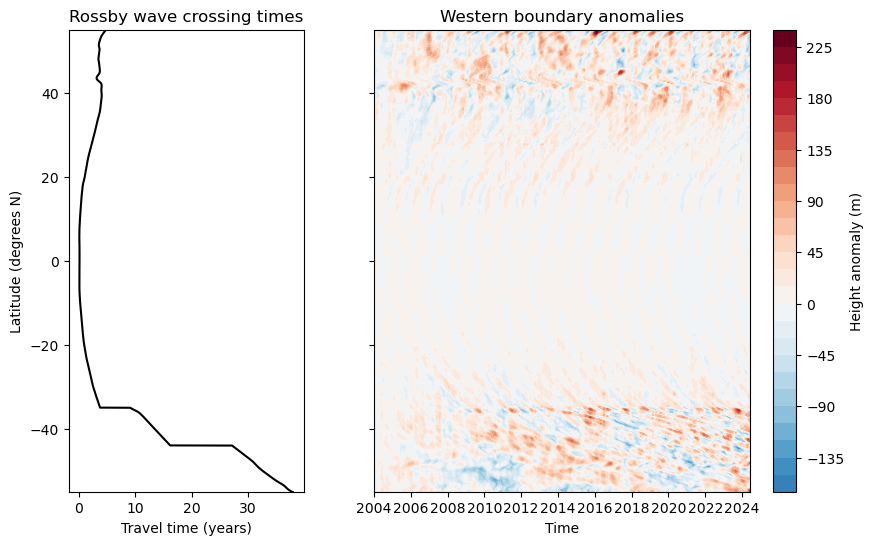

In [6]:
## Create a two-panel figure to plot the travel times and western boundary anomalies in the Atlantic
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 6), sharey=True, width_ratios=[1, 2])
# Plot travel times
tt_yr = tt / (24 * 60 * 60 * 365.25) # Convert seconds to years
tt_ax = axs[0]
tt_ax.plot(tt_yr, tt_yr.latitude, color="black")
tt_ax.set_xlabel("Travel time (years)")
tt_ax.set_ylabel("Latitude (degrees N)")
tt_ax.set_title("Rossby wave crossing times")
# Plot height anomalies
h_b_ax = axs[1]
vmax = np.max(np.abs(h_b.T))
ctf = h_b_ax.contourf(h_b.time, h_b.latitude, h_b.T, cmap="RdBu_r", levels=31, vmin=-vmax, vmax=vmax)
h_b_ax.set_xlabel("Time")
plt.colorbar(ctf, ax=h_b_ax, label="Height anomaly (m)")
h_b_ax.set_title("Western boundary anomalies")
h_b_ax.set_ylim([h_b.latitude.min(), h_b.latitude.max()])

Interestingly, the magnitude of the anomalies in the far South Atlantic are similar to those in the North Atlantic, even though the crossing times are much longer in the South. This indicates stronger mean North Atlantic wind anomalies along the Rossby waves. We can compare the variability in $h_b$ as a function of latitude to the zonal mean variability in $w_{Ek}$ also as a function of latitude:
$$\sigma_{h_b} \sim \frac{L}{c} \sigma_{w_{Ek}}$$

In [7]:
# Compute the Ekman upwelling as the divergence of the forcing
x_contribution = forcing_ds.M_Ek_x.differentiate("longitude") / (EARTH_RADIUS_M * np.cos(np.radians(forcing_ds.latitude)) * np.radians(1))
y_contribution = (forcing_ds.M_Ek_y * np.cos(np.radians(forcing_ds.latitude))).differentiate("latitude") / (EARTH_RADIUS_M * np.cos(np.radians(forcing_ds.latitude)) * np.radians(1))
w_Ek = (x_contribution + y_contribution)
# Mask the upwelling only to the Atlantic basin
x_w_forcing = x_w.interp(latitude=w_Ek.latitude)
x_e_forcing = x_e.interp(latitude=w_Ek.latitude)

spatial_mask = (
    (w_Ek.longitude >= x_w_forcing)
    & (w_Ek.longitude <= x_e_forcing)
)
w_Ek_atlantic = w_Ek.where(spatial_mask)
zonal_mean_w_Ek_std = w_Ek_atlantic.std(dim="time").mean(dim="longitude")

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [8]:
# Ccompute the variability in h_b as a function of latitude
h_b_std = h_b.std(dim="time")
# Product of travel time and Ekman upwelling variability
tt_on_forcing = tt.interp(latitude=zonal_mean_w_Ek_std.latitude)
tau_times_w_Ek_std = tt_on_forcing * zonal_mean_w_Ek_std
tau_times_w_Ek_std = tau_times_w_Ek_std.interp(latitude=h_b_std.latitude)

Text(0.5, 1.0, 'Scatter plot of the two variabilities')

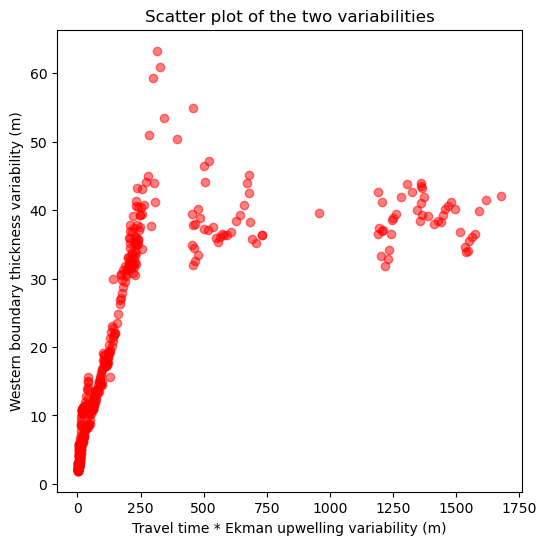

In [9]:
## Create a figure
fig = plt.figure(figsize=(6, 6))
scatter_ax = fig.add_subplot(111)
scatter_ax.scatter(tau_times_w_Ek_std, h_b_std, color="red", alpha=0.5)
scatter_ax.set_xlabel("Travel time * Ekman upwelling variability (m)")
scatter_ax.set_ylabel("Western boundary thickness variability (m)")
scatter_ax.set_title("Scatter plot of the two variabilities")
# scatter_ax.set_xscale("log")
# scatter_ax.set_yscale("log")

### Latitude structure and regression fits
The points below are coloured by latitude to expose the different geographical branches. Both regressions use all points at latitudes north of $y_I$ (inclusive). Points between $y_P$ and $y_I$ are marked with crosses, while points south of $y_P$ are marked with open circles. The power-law fit is estimated by ordinary least squares after taking $\log_{10}$ of both positive quantities.

In [10]:
# Select all latitudes north of y_I (inclusive) for both regressions
y_I_value = y_I.item()
y_P_value = y_P.item()

regression_x, regression_y = xr.align(
    tau_times_w_Ek_std, h_b_std, join="inner"
)
x_values = regression_x.values
y_values = regression_y.values
latitude_values = regression_x.latitude.values

finite_mask = (
    np.isfinite(x_values)
    & np.isfinite(y_values)
    & np.isfinite(latitude_values)
)
positive_mask = finite_mask & (x_values > 0) & (y_values > 0)
north_of_y_I_mask = finite_mask & (latitude_values >= y_I_value)
between_y_P_y_I_mask = (
    finite_mask
    & (latitude_values >= y_P_value)
    & (latitude_values < y_I_value)
)
south_of_y_P_mask = finite_mask & (latitude_values < y_P_value)
regression_mask = north_of_y_I_mask

if regression_mask.sum() < 3:
    raise ValueError("The selected regression regime contains fewer than three points")
if not np.all((x_values[regression_mask] > 0) & (y_values[regression_mask] > 0)):
    raise ValueError("The northern regression points must be positive for the log-log fit")

x_regression = x_values[regression_mask]
y_regression = y_values[regression_mask]

# Ordinary least-squares linear fit: y = slope * x + intercept
linear_slope, linear_intercept = np.polyfit(x_regression, y_regression, 1)
linear_prediction = linear_slope * x_regression + linear_intercept
linear_r_squared = 1 - (
    np.sum((y_regression - linear_prediction) ** 2)
    / np.sum((y_regression - y_regression.mean()) ** 2)
)

# Log-log ordinary least-squares fit: y = coefficient * x ** exponent
log_x_regression = np.log10(x_regression)
log_y_regression = np.log10(y_regression)
power_exponent, log10_power_coefficient = np.polyfit(
    log_x_regression, log_y_regression, 1
)
power_coefficient = 10 ** log10_power_coefficient
log_prediction = power_exponent * log_x_regression + log10_power_coefficient
power_r_squared = 1 - (
    np.sum((log_y_regression - log_prediction) ** 2)
    / np.sum((log_y_regression - log_y_regression.mean()) ** 2)
)

print(
    f"Regression regime: latitude >= y_I = {y_I_value:.3f}\N{DEGREE SIGN}N "
    f"({regression_mask.sum()} points)"
)
print(f"Linear: y = {linear_slope:.4f} x + {linear_intercept:.3f}; R^2 = {linear_r_squared:.4f}")
print(f"Power law: y = {power_coefficient:.4f} x^{power_exponent:.4f}; log-space R^2 = {power_r_squared:.4f}")

Regression regime: latitude >= y_I = -34.992°N (361 points)
Linear: y = 0.1433 x + 3.451; R^2 = 0.9595
Power law: y = 1.1953 x^0.6043; log-space R^2 = 0.9416


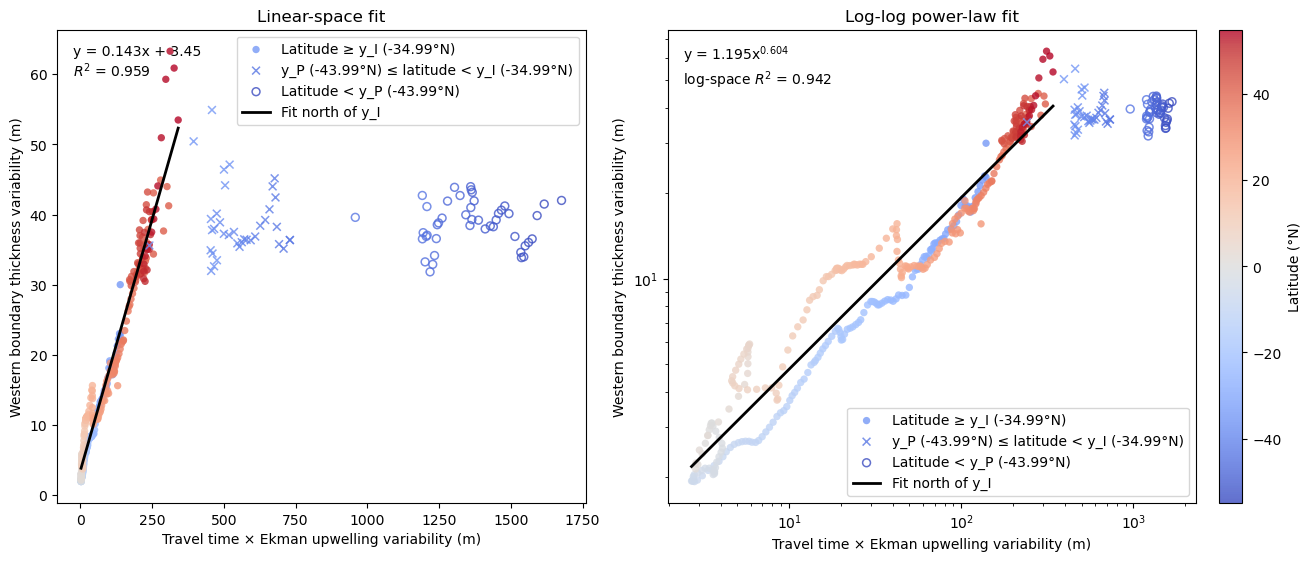

In [11]:
# Show the latitude branches and both fitted relationships
fig, axes = plt.subplots(
    nrows=1, ncols=2, figsize=(13, 5.5), layout="constrained"
)

latitude_norm = plt.Normalize(
    vmin=latitude_values[finite_mask].min(),
    vmax=latitude_values[finite_mask].max(),
)

scatter = axes[0].scatter(
    x_values[north_of_y_I_mask],
    y_values[north_of_y_I_mask],
    c=latitude_values[north_of_y_I_mask],
    cmap="coolwarm",
    norm=latitude_norm,
    s=28,
    alpha=0.8,
    edgecolors="none",
    marker="o",
    label=f"Latitude \N{GREATER-THAN OR EQUAL TO} y_I ({y_I_value:.2f}\N{DEGREE SIGN}N)",
)
axes[0].scatter(
    x_values[between_y_P_y_I_mask],
    y_values[between_y_P_y_I_mask],
    c=latitude_values[between_y_P_y_I_mask],
    cmap="coolwarm",
    norm=latitude_norm,
    s=32,
    alpha=0.8,
    linewidths=1.1,
    marker="x",
    label=(
        f"y_P ({y_P_value:.2f}\N{DEGREE SIGN}N) \N{LESS-THAN OR EQUAL TO} latitude < "
        f"y_I ({y_I_value:.2f}\N{DEGREE SIGN}N)"
    ),
)
latitude_cmap = plt.get_cmap("coolwarm")
axes[0].scatter(
    x_values[south_of_y_P_mask],
    y_values[south_of_y_P_mask],
    facecolors="none",
    edgecolors=latitude_cmap(latitude_norm(latitude_values[south_of_y_P_mask])),
    s=32,
    alpha=0.8,
    linewidths=1.1,
    marker="o",
    label=f"Latitude < y_P ({y_P_value:.2f}\N{DEGREE SIGN}N)",
)
linear_fit_x = np.linspace(x_regression.min(), x_regression.max(), 300)
axes[0].plot(
    linear_fit_x,
    linear_slope * linear_fit_x + linear_intercept,
    color="black",
    linewidth=2,
    label="Fit north of y_I",
)
axes[0].set(
    xlabel="Travel time \N{MULTIPLICATION SIGN} Ekman upwelling variability (m)",
    ylabel="Western boundary thickness variability (m)",
    title="Linear-space fit",
)
axes[0].legend()
axes[0].text(
    0.03,
    0.97,
    f"y = {linear_slope:.3f}x + {linear_intercept:.2f}\n"
    f"$R^2$ = {linear_r_squared:.3f}",
    transform=axes[0].transAxes,
    va="top",
)

north_positive_mask = positive_mask & (latitude_values >= y_I_value)
between_y_P_y_I_positive_mask = (
    positive_mask
    & (latitude_values >= y_P_value)
    & (latitude_values < y_I_value)
)
south_of_y_P_positive_mask = positive_mask & (latitude_values < y_P_value)
axes[1].scatter(
    x_values[north_positive_mask],
    y_values[north_positive_mask],
    c=latitude_values[north_positive_mask],
    cmap="coolwarm",
    norm=latitude_norm,
    s=28,
    alpha=0.8,
    edgecolors="none",
    marker="o",
    label=f"Latitude \N{GREATER-THAN OR EQUAL TO} y_I ({y_I_value:.2f}\N{DEGREE SIGN}N)",
)
axes[1].scatter(
    x_values[between_y_P_y_I_positive_mask],
    y_values[between_y_P_y_I_positive_mask],
    c=latitude_values[between_y_P_y_I_positive_mask],
    cmap="coolwarm",
    norm=latitude_norm,
    s=32,
    alpha=0.8,
    linewidths=1.1,
    marker="x",
    label=(
        f"y_P ({y_P_value:.2f}\N{DEGREE SIGN}N) \N{LESS-THAN OR EQUAL TO} latitude < "
        f"y_I ({y_I_value:.2f}\N{DEGREE SIGN}N)"
    ),
)
axes[1].scatter(
    x_values[south_of_y_P_positive_mask],
    y_values[south_of_y_P_positive_mask],
    facecolors="none",
    edgecolors=latitude_cmap(
        latitude_norm(latitude_values[south_of_y_P_positive_mask])
    ),
    s=32,
    alpha=0.8,
    linewidths=1.1,
    marker="o",
    label=f"Latitude < y_P ({y_P_value:.2f}\N{DEGREE SIGN}N)",
)
power_fit_x = np.geomspace(x_regression.min(), x_regression.max(), 300)
axes[1].plot(
    power_fit_x,
    power_coefficient * power_fit_x ** power_exponent,
    color="black",
    linewidth=2,
    label="Fit north of y_I",
)
axes[1].set(
    xscale="log",
    yscale="log",
    xlabel="Travel time \N{MULTIPLICATION SIGN} Ekman upwelling variability (m)",
    ylabel="Western boundary thickness variability (m)",
    title="Log-log power-law fit",
)
axes[1].legend()
axes[1].text(
    0.03,
    0.97,
    f"y = {power_coefficient:.3f}x$^{{{power_exponent:.3f}}}$\n"
    f"log-space $R^2$ = {power_r_squared:.3f}",
    transform=axes[1].transAxes,
    va="top",
)

fig.colorbar(scatter, ax=axes, label="Latitude (\N{DEGREE SIGN}N)", pad=0.02)
plt.show()

The picture emerging here is interesting. North of $y_I$, there is very much a linear correlation between these two quantities. However, south of here, it looks like this breaks down and the thickness variability becomes about constant. The two clusters are pretty clearly north and south of $y_P$, with the spread likely only due to the travel time growing as we move south. Its almost like the variability saturates once you leave the Atlantic. Let's zoom in on those a bit more, by plotting Ekman upwelling variability against western boundary thickness variability (I don't think that the travel time is having an effect here).

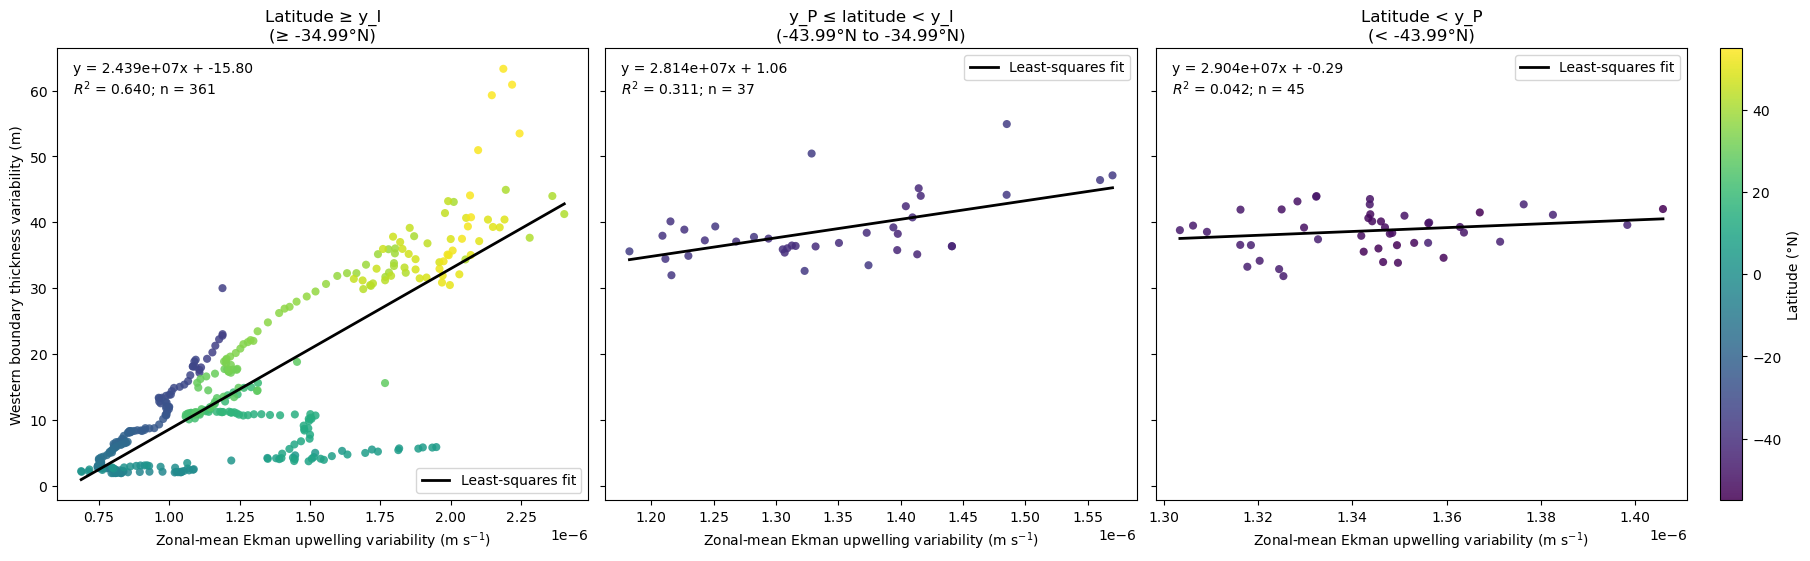

In [12]:
zonal_mean_w_Ek_std_on_h_b_std = zonal_mean_w_Ek_std.interp(
    latitude=h_b_std.latitude
)
wind_std_for_plot, h_b_std_for_plot = xr.align(
    zonal_mean_w_Ek_std_on_h_b_std, h_b_std, join="inner"
)

sector_specs = [
    (
        wind_std_for_plot.latitude >= y_I_value,
        f"Latitude \N{GREATER-THAN OR EQUAL TO} y_I\n(\N{GREATER-THAN OR EQUAL TO} {y_I_value:.2f}\N{DEGREE SIGN}N)",
    ),
    (
        (wind_std_for_plot.latitude >= y_P_value)
        & (wind_std_for_plot.latitude < y_I_value),
        (
            f"y_P \N{LESS-THAN OR EQUAL TO} latitude < y_I\n"
            f"({y_P_value:.2f}\N{DEGREE SIGN}N to {y_I_value:.2f}\N{DEGREE SIGN}N)"
        ),
    ),
    (
        wind_std_for_plot.latitude < y_P_value,
        f"Latitude < y_P\n(< {y_P_value:.2f}\N{DEGREE SIGN}N)",
    ),
]

fig, axes = plt.subplots(
    nrows=1, ncols=3, figsize=(18, 5.5), sharey=True, layout="constrained"
)
shared_latitude_norm = plt.Normalize(
    vmin=wind_std_for_plot.latitude.min().item(),
    vmax=wind_std_for_plot.latitude.max().item(),
)

for ax, (sector_mask, title) in zip(axes, sector_specs):
    sector_x = wind_std_for_plot.where(sector_mask, drop=True).values
    sector_y = h_b_std_for_plot.where(sector_mask, drop=True).values
    sector_latitude = (
        wind_std_for_plot.latitude.where(sector_mask, drop=True).values
    )
    valid = (
        np.isfinite(sector_x)
        & np.isfinite(sector_y)
        & np.isfinite(sector_latitude)
    )
    sector_x = sector_x[valid]
    sector_y = sector_y[valid]
    sector_latitude = sector_latitude[valid]

    if sector_x.size < 3:
        raise ValueError(f"{title} contains fewer than three valid points")

    slope, intercept = np.polyfit(sector_x, sector_y, 1)
    fitted_y = slope * sector_x + intercept
    r_squared = 1 - (
        np.sum((sector_y - fitted_y) ** 2)
        / np.sum((sector_y - sector_y.mean()) ** 2)
    )

    scatter = ax.scatter(
        sector_x,
        sector_y,
        c=sector_latitude,
        cmap="viridis",
        norm=shared_latitude_norm,
        s=34,
        alpha=0.85,
        edgecolors="none",
    )
    fit_x = np.linspace(sector_x.min(), sector_x.max(), 300)
    ax.plot(
        fit_x,
        slope * fit_x + intercept,
        color="black",
        linewidth=2,
        label="Least-squares fit",
    )
    ax.set(
        xlabel="Zonal-mean Ekman upwelling variability (m s$^{-1}$)",
        title=title,
    )
    ax.legend()
    ax.text(
        0.03,
        0.97,
        f"y = {slope:.3e}x + {intercept:.2f}\n"
        f"$R^2$ = {r_squared:.3f}; n = {sector_x.size}",
        transform=ax.transAxes,
        va="top",
    )
axes[0].set_ylabel("Western boundary thickness variability (m)")
fig.colorbar(
    scatter, ax=axes, label="Latitude (\N{DEGREE SIGN}N)", pad=0.02
)
plt.show()

So it seems like the thickness variability is roughly the Ekman upwelling variability times a particular timescale. That timescale, however, varies with latitude / region. In the rapidly-adjusting Atlantic, the timescale is some multiple of the basin crossing time, whereas in the other basins this is something else. In reality there might be a damping factor at play, that is, a latitude-dependent constant in front so that:
$$
\sigma_{h_b} = \alpha(y)\frac{L}{c}\sigma_{w_{Ek}}
$$

Based on this hypothesis, we can just directly define this dimensionless damping factor as such:
$$
\alpha(y) := \frac{\sigma_{h_b}}{\sigma_{w_{Ek}}}\frac{c}{L}
$$
and plot it as a function of latitude.

Text(0, 0.5, 'Latitude (°N)')

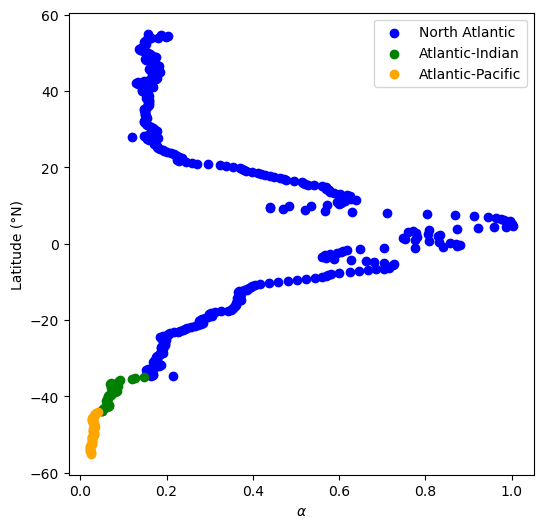

In [76]:
alpha = h_b_std / tau_times_w_Ek_std
alpha_NA = alpha.sel(latitude=slice(y_I_value, None))
alpha_AI = alpha.sel(latitude=slice(y_P, y_I_value))
alpha_AP = alpha.sel(latitude=slice(None, y_P_value))
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111)
ax.scatter(alpha_NA.values, alpha_NA.latitude.values, label="North Atlantic", color="blue")
ax.scatter(alpha_AI.values, alpha_AI.latitude.values, label="Atlantic-Indian", color="green")
ax.scatter(alpha_AP.values, alpha_AP.latitude.values, label="Atlantic-Pacific", color="orange")
ax.legend()
ax.set_xlabel(r"$\alpha$")
ax.set_ylabel("Latitude (\N{DEGREE SIGN}N)")

Earlier I thought that the latitudes with highest $h_b$ variability seem to be the ones furthest north, due to anomalous upwelling created by the wind taper. I don't think this is necessarily false, but I'm of two minds now. Because when I look at $\alpha(y)$, it seems like we are seeing a pattern basically symmetric about the equator until we reach $y_I$. The Atlantic-Indian basin is a bit weird, whereas the Atlantic-Pacific basin appears to have a constant very small $\alpha$.

There's a question about whether or not this is due to the zonally inhomogeneous winds. If we use a wind field that does not vary zonally but has the same sort of character as the full forcing, do we see the same behaviour?